In [99]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

# Pregunta 1

/tmp/ipykernel_7579/2454121797.py:3: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.hist(tomates.ravel(),256,[0,256],color="black"); plt.show()


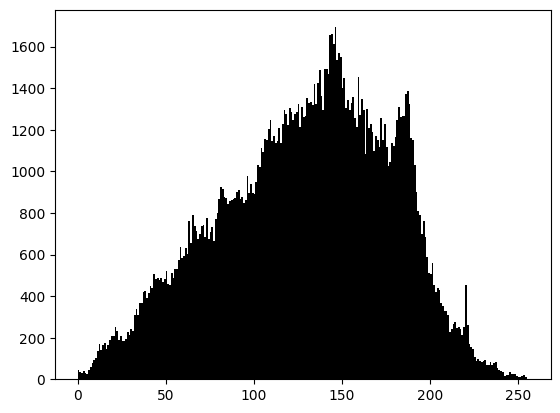

In [100]:
# Histograma de tomates.png
tomates = cv.imread('Files/01_Prim/tomates.png', cv.IMREAD_GRAYSCALE)
plt.hist(tomates.ravel(),256,[0,256],color="black"); plt.show()

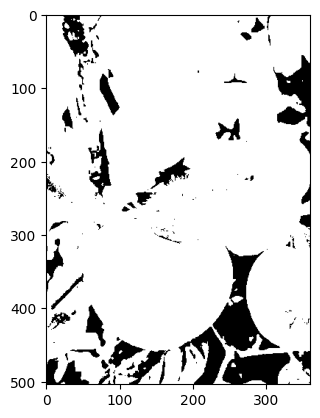

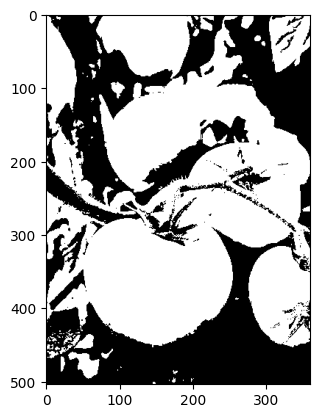

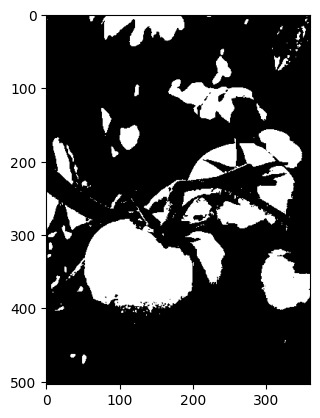

In [101]:
# Binarización de tomates.png usando 3 umbrales
umbrales = [70, 120, 170]
for umbral in umbrales:
    _, temp = cv.threshold(tomates, umbral, 255, cv.THRESH_BINARY)
    plt.imshow(temp, cmap='gray')
    plt.show()

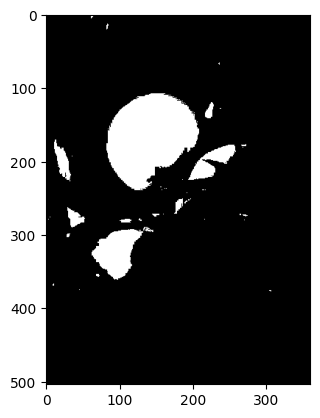

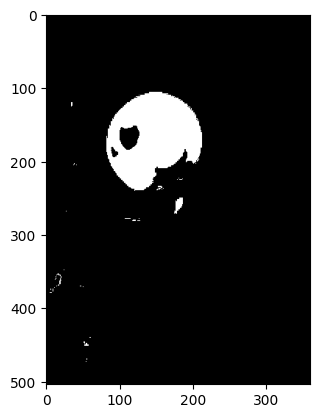

In [102]:
# Mascara para detectar el tomate rojo utilizando el canal rojo
rojo = cv.imread('Files/01_Prim/tomates.png', cv.IMREAD_COLOR)[:,:,2]
_, mask = cv.threshold(rojo, 230, 255, cv.THRESH_BINARY)
plt.imshow(mask, cmap='gray')
plt.show()

# Mascara para detectar el tomate verde utilizando el canal rojo y verde
verde = cv.imread('Files/01_Prim/tomates.png', cv.IMREAD_COLOR)[:,:,1]
_, mask_verde = cv.threshold(verde, 160, 255, cv.THRESH_BINARY)
mask_verde = cv.bitwise_not(mask_verde)
_, mask_rojo = cv.threshold(rojo, 200, 255, cv.THRESH_BINARY)
mask_tomate_verde = cv.bitwise_and(mask_verde, mask_rojo)
plt.imshow(mask_tomate_verde, cmap='gray')
plt.show()

# Pregunta 2

# Pregunta 3

# Pregunta 4

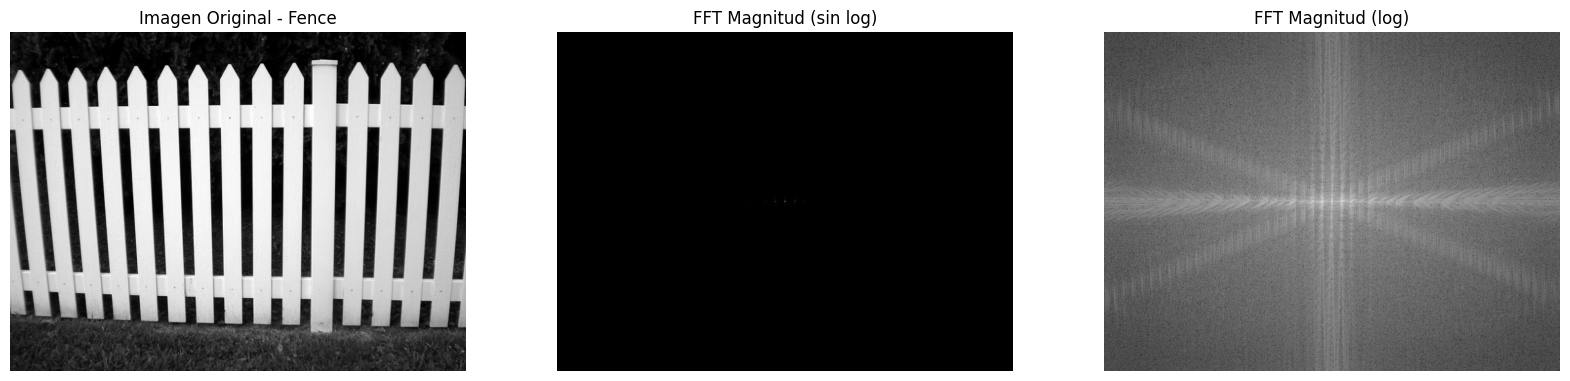

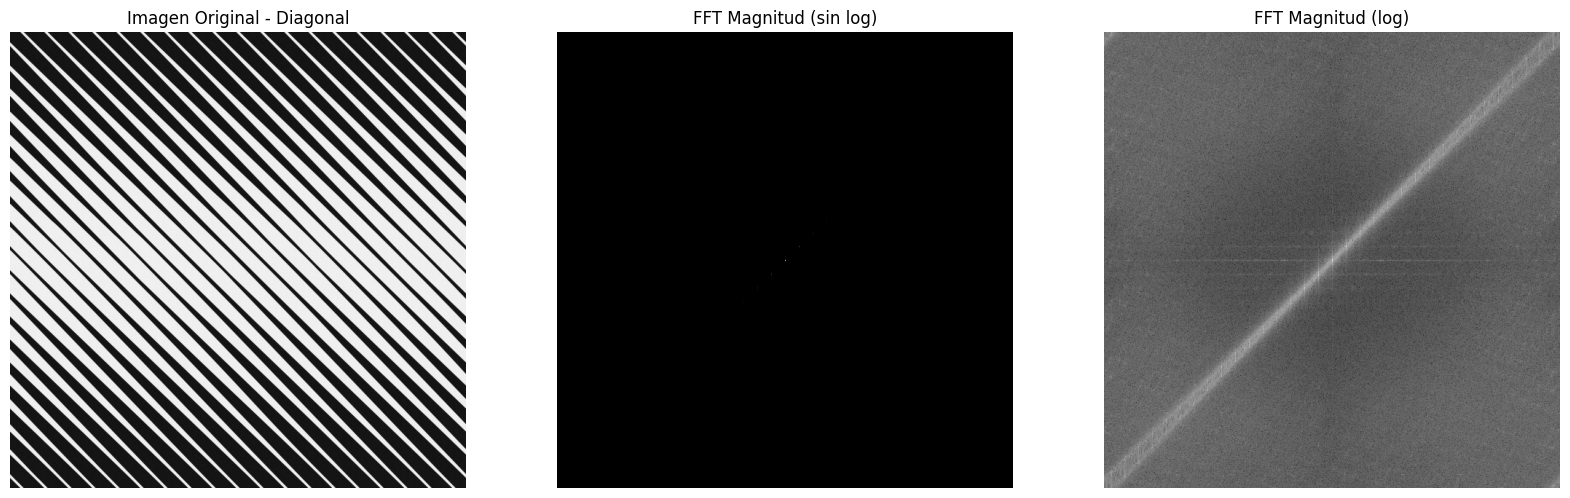

In [114]:
# Transformada de Fourier 2D y su visualización con y sin escala logarítmica
fence = cv.imread("Files/01_Prim/fence.png", cv.IMREAD_GRAYSCALE)
diagonal = cv.imread("Files/01_Prim/diagonal.jpg", cv.IMREAD_GRAYSCALE)


def fourier_transform(img_gray, title):
    # 1. Transformada de Fourier 2D
    f = np.fft.fft2(img_gray)
    fshift = np.fft.fftshift(f)
    magnitude = np.abs(fshift)

    # 2. Transformación logarítmica
    R = magnitude.max()
    c = 255 / np.log(1 + R)
    log_magnitude = c * np.log(1 + magnitude)
    fig, axs = plt.subplots(1, 3, figsize=(20,10))

    axs[0].imshow(img_gray, cmap='gray')
    axs[0].set_title(f'Imagen Original - {title}')
    axs[0].axis('off')

    axs[1].imshow(magnitude, cmap='gray')
    axs[1].set_title('FFT Magnitud (sin log)')
    axs[1].axis('off')

    axs[2].imshow(log_magnitude, cmap='gray')
    axs[2].set_title('FFT Magnitud (log)')
    axs[2].axis('off')

    plt.show()



fourier_transform(fence, "Fence")
fourier_transform(diagonal, "Diagonal")

